In [ ]:
# ── KAGGLE SETUP (only runs on Kaggle, no-op everywhere else) ───────────────
import os, sys
from pathlib import Path

if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or Path("/kaggle/input").exists():
    import subprocess
    # Force stable PyTorch (CUDA 12.1) — avoids cudaErrorNoKernelImageForDevice
    # on any Kaggle GPU (P100/T4/A100/L4) regardless of which is assigned.
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "torch==2.4.1", "torchvision==0.19.1",
        "--index-url", "https://download.pytorch.org/whl/cu121",
        "--force-reinstall",
    ], check=True)
    REPO_URL = "https://github.com/ltruonghai257/fake-new-detection.git"
    CLONE_DIR = Path("/kaggle/working/fake-news-detection")
    if not CLONE_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(CLONE_DIR)], check=True)
        print(f"Cloned → {CLONE_DIR}")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r",
         str(CLONE_DIR / "requirements.txt")], check=True,
    )
    def _find_hdf5_root():
        for d in Path("/kaggle/input").rglob("processed_data/hdf5"):
            if d.is_dir(): return d.parent.parent
        return None
    hdf5_root = _find_hdf5_root()
    if hdf5_root is None:
        raise RuntimeError("processed_data/hdf5/ not found under /kaggle/input/")
    (CLONE_DIR / ".env.kaggle").write_text(f"DATA_ROOT={hdf5_root}\nPLATFORM=kaggle\n")
    print(f"DATA_ROOT={hdf5_root}")
else:
    print("Not Kaggle — setup skipped.")

In [2]:
# ── Environment + path setup ────────────────────────────────────────────────
import os, sys
from pathlib import Path

def _detect_platform():
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or Path("/kaggle/input").exists():
        return "kaggle"
    try:
        import google.colab; return "colab"
    except ImportError: pass
    if Path("/workspace").exists(): return "vastai"
    if sys.platform == "darwin": return "mac"
    return "windows"

PLATFORM = _detect_platform()

try:
    _nb_path = Path(__file__).resolve()
except NameError:
    _nb_path = Path.cwd()

if PLATFORM == "colab":
    from google.colab import drive; drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/Thesis_Final/fake-news-detection")
elif PLATFORM == "kaggle":
    PROJECT_ROOT = Path(os.environ.get("KAGGLE_PROJECT_ROOT", "/kaggle/working/fake-news-detection"))
else:
    PROJECT_ROOT = _nb_path.parents[1] if _nb_path.name.endswith(".ipynb") else Path.cwd().parents[1]

sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
_env_file = PROJECT_ROOT / f".env.{PLATFORM}"
if not _env_file.exists(): _env_file = PROJECT_ROOT / ".env"
load_dotenv(_env_file, override=True)

from src.utils.env_utils import get_data_root
DATA_ROOT = get_data_root()
print(f"Platform : {PLATFORM}")
print(f"DATA_ROOT: {DATA_ROOT}  (exists={DATA_ROOT.exists()})")

Platform : kaggle
DATA_ROOT: /kaggle/input/datasets/trnghil/coolant-train-new  (exists=True)


# COOLANT v2 — Paper-Faithful Training (GatedMLP)

Paper: *Cross-modal Contrastive Learning for Multimodal Fake News Detection* (ACM MM '23)

**Loss schedule per §3.2 (paper gốc, `use_itc=True`):**
```
Task 1a — Consistency:  L_ITM = CosineEmbeddingLoss(e_s_t, e_s_v, ±1)   §3.2.1
Task 1b — Contrastive:  L_ITC = symmetric InfoNCE(m_t, m_v)               §3.2.2
Task 1c — Soft distill: L_SEM = soft-CE(S_ITM → P_ITC)                   §3.2.4
           Combined:     L_CL  = L_ITC + λ·L_SEM                          Eq. 7
Task 2  — Detection:    L_DET = L_CE + 0.5·L_KL                          §3.4.3
```

**Notation (paper → code):**
- `e_s_t`, `e_s_v` — shared embeddings from `SimilarityModule` (→ L_ITM, soft targets)
- `m_t`,   `m_v`   — aligned representations from `CLIPModule`  (→ L_ITC, CrossModule)

**Modifications vs paper:** only GatedMLP (SwiGLU) replaces standard MLPs.

**`use_itc=False`** = ablation mode (only L_ITM + L_DET, no CLIPModule).

In [ ]:
# ── CONFIG — edit this cell only ────────────────────────────────────────────
CONFIG = {
    "paths": {
        "train_hdf5": DATA_ROOT / "processed_data" / "hdf5" / "coolant_train.h5",
        "dev_hdf5":   DATA_ROOT / "processed_data" / "hdf5" / "coolant_dev.h5",
        "test_hdf5":  DATA_ROOT / "processed_data" / "hdf5" / "coolant_test.h5",
        "checkpoint_root": DATA_ROOT / "training" / "checkpoints_coolant_v2",
    },
    "model": {
        # Feature dimensions (match HDF5 preprocessing output)
        "text_input_dim":  768,   # PhoBERT embed dim
        "image_input_dim": 2048,  # ResNet50 feature dim
        # COOLANT_Official architecture
        "shared_dim":  128,
        "sim_dim":      64,
        "feature_dim":  96,   # 64 + 16 + 16
        "h_dim":        64,
        # Paper §3.2: use_itc=True = full paper (L_ITM + L_ITC + L_SEM + L_DET)
        # use_itc=False = ablation (L_ITM + L_DET only, no CLIPModule)
        "use_itc":        True,
        "clip_embed_dim": 64,
        "sem_weight":      1.0,   # λ in L_CL = L_ITC + λ·L_SEM  (Eq. 7)
        "itm_weight":      0.5,   # weight of L_ITM relative to L_CL
    },
    "training": {
        "batch_size":              64,
        "max_epochs":             80,
        "negative_shift":           3,
        "min_batch_for_negatives":  4,
        "grad_clip":              1.0,
        "grad_accumulation_steps":  4,    # ↑ from 2 — more stable gradients per step
        "warmup_epochs":            5,    # ↑ from 3 — slower ramp-up reduces early instability
        "lr":                    3e-4,    # ↓ from 1e-3 — reduces class-collapse oscillation
        "weight_decay":          1e-2,    # ↑ from 1e-5 — standard AdamW L2 regularization
        "seed":                    42,
        "detection_weight":       1.0,
    },
    "checkpointing": {
        "selection_metric": "val_macro_f1",
        "checkpoint_every":  5,
    },
    "safety": {
        "smoke_test":            False,
        "smoke_batches":             2,
        "resume_from_checkpoint": None,
    },
}

# Kaggle: redirect writable outputs
if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or Path("/kaggle/input").exists():
    CONFIG["paths"]["checkpoint_root"] = Path("/kaggle/working/checkpoints_coolant_v2")

CONFIG["paths"]["checkpoint_root"].mkdir(parents=True, exist_ok=True)
print("CONFIG loaded.")

In [4]:
# ── Imports ──────────────────────────────────────────────────────────────────
import gc, json, random, hashlib
from copy import deepcopy
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report

# Project modules
from src.models.coolant_official import COOLANT_Official
from src.preprocessing.coolant.pair_dataset import create_coolant_dataloaders
from src.preprocessing.coolant.training_utils import make_coolant_pairs, make_detection_batch

print(f"PyTorch: {torch.__version__}")

/kaggle/working/fake-news-detection/src/preprocessing/text_preprocessing.py:210: SyntaxWarning: invalid escape sequence '\['
  vietnamese_punctuation = r'[.,;:!?""' "(){}\[\]\\/|`~@#$%^&*+=<>—–]"


PyTorch: 2.14.0+cu130


In [5]:
# ── Device, seed, dataloaders ────────────────────────────────────────────────
def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else
                      "mps"  if torch.backends.mps.is_available() else "cpu")
seed_everything(CONFIG["training"]["seed"])
print(f"Device: {DEVICE}")

loaders, datasets = create_coolant_dataloaders(
    str(CONFIG["paths"]["train_hdf5"]),
    str(CONFIG["paths"]["dev_hdf5"]),
    str(CONFIG["paths"]["test_hdf5"]),
    batch_size=CONFIG["training"]["batch_size"],
)

if CONFIG["safety"]["smoke_test"]:
    from itertools import islice
    class _SmokeLoader:
        def __init__(self, l, n): self._l, self._n = l, n
        def __iter__(self): return islice(self._l, self._n)
        def __len__(self): return min(self._n, len(self._l))
    loaders = {k: _SmokeLoader(v, CONFIG["safety"]["smoke_batches"]) for k, v in loaders.items()}
    print(f"SMOKE TEST: {CONFIG['safety']['smoke_batches']} batches/split")

# Verify shapes
_cap, _img, _ = next(iter(loaders["train"]))
print(f"caption: {tuple(_cap.shape)}  (B, embed=768, seq=128)")
print(f"image:   {tuple(_img.shape)}  (B, 2048)")

Device: cuda
CoolantPairDataset: 6724 pairs from coolant_train.h5
CoolantPairDataset: 862 pairs from coolant_dev.h5
CoolantPairDataset: 2053 pairs from coolant_test.h5

COOLANT DataLoaders created:
  Train: 106 batches (6724 pairs)
  Dev:   14 batches (862 pairs)
  Test:  33 batches (2053 pairs)
caption: (64, 768, 128)  (B, embed=768, seq=128)
image:   (64, 2048)  (B, 2048)


In [6]:
# ── Build COOLANT_Official ───────────────────────────────────────────────────
model_cfg = {
    "text_input_dim":  CONFIG["model"]["text_input_dim"],
    "image_input_dim": CONFIG["model"]["image_input_dim"],
    "text_seq_len":    CONFIG["model"].get("text_seq_len", 128),
    "shared_dim":      CONFIG["model"]["shared_dim"],
    "sim_dim":         CONFIG["model"]["sim_dim"],
    "feature_dim":     CONFIG["model"]["feature_dim"],
    "h_dim":           CONFIG["model"]["h_dim"],
    "use_itc":         CONFIG["model"]["use_itc"],
    "clip_embed_dim":  CONFIG["model"]["clip_embed_dim"],
    "sem_weight":      CONFIG["model"]["sem_weight"],  # λ for L_SEM (§3.2.4)
    "itm_weight":      CONFIG["model"]["itm_weight"],
}
model = COOLANT_Official(model_cfg).to(DEVICE)

total_p = sum(p.numel() for p in model.parameters())
sim_p   = sum(p.numel() for p in model.similarity_module.parameters())
det_p   = sum(p.numel() for p in model.detection_module.parameters())
print(f"Parameters total:                    {total_p:,}")
print(f"  SimilarityModule (L_ITM, §3.2.1):  {sim_p:,}")
if model.use_itc:
    itc_p = sum(p.numel() for p in model.clip_module.parameters())
    print(f"  CLIPModule       (L_ITC, §3.2.2):  {itc_p:,}")
print(f"  DetectionModule  (L_DET, §3.4):    {det_p:,}")
print(f"\nuse_itc = {model.use_itc}  →  {'Full paper (L_ITM+L_ITC+L_SEM+L_DET)' if model.use_itc else 'Ablation (L_ITM+L_DET)'}")

Parameters total:                    6,456,460
  SimilarityModule (L_ITM, §3.2.1):  1,043,136
  CLIPModule       (L_ITC, §3.2.2):  1,474,561
  DetectionModule  (L_DET, §3.4):    3,938,763

use_itc = True  →  Full paper (L_ITM+L_ITC+L_SEM+L_DET)


In [7]:
# ── Losses, optimizers, LR schedulers ───────────────────────────────────────
# Loss functions (built-in, only L_CE/L_KL; L_ITM/L_ITC/L_SEM via model methods)
loss_ce = nn.CrossEntropyLoss(label_smoothing=0.05)   # part of L_DET
loss_kl = nn.KLDivLoss(reduction="batchmean")          # part of L_DET

def _make_optim(params, lr=None):
    _lr = lr or CONFIG["training"]["lr"]
    _wd = CONFIG["training"]["weight_decay"]
    return torch.optim.AdamW(params, lr=_lr, betas=(0.9, 0.999),
                             eps=1e-8, weight_decay=_wd)

# One optimizer per module (paper approach)
OPTIMIZERS = {
    "similarity": _make_optim(model.similarity_module.parameters()),  # Task 1a L_ITM
    "detection":  _make_optim(model.detection_module.parameters()),   # Task 2  L_DET
}
if model.use_itc:
    # CLIPModule trained with L_CL = L_ITC + λ·L_SEM
    OPTIMIZERS["itc"] = _make_optim(model.clip_module.parameters())

def _make_scheduler(opt):
    wu = CONFIG["training"]["warmup_epochs"]
    T  = CONFIG["training"]["max_epochs"]
    def _lr(ep):
        if ep < wu: return ep / max(1, wu)
        p = (ep - wu) / max(1, T - wu)
        return max(0.0, 0.5 * (1 + torch.cos(torch.tensor(3.14159265 * p)).item()))
    return torch.optim.lr_scheduler.LambdaLR(opt, _lr)

SCHEDULERS = {k: _make_scheduler(opt) for k, opt in OPTIMIZERS.items()}
print(f"Optimizers: {list(OPTIMIZERS.keys())}  (AdamW)")
print(f"Scheduler: warmup={CONFIG['training']['warmup_epochs']}, cosine to epoch {CONFIG['training']['max_epochs']}")

Optimizers: ['similarity', 'detection', 'itc']  (AdamW)
Scheduler: warmup=3, cosine to epoch 80


In [8]:
# ── One-batch sanity check ───────────────────────────────────────────────────
model.train()
_cap, _img, _ = next(iter(loaders["train"]))
_cap, _img = _cap.to(DEVICE), _img.to(DEVICE)

# Task 1a: L_ITM — consistency (§3.2.1)
_cap_a, _img_m, _img_u = make_coolant_pairs(_cap, _img, shift=CONFIG["training"]["negative_shift"])
_e_s_t_m, _e_s_v_m, _ = model.similarity_module(_cap_a, _img_m)
_e_s_t_u, _e_s_v_u, _ = model.similarity_module(_cap_a, _img_u)
_lbl_m = torch.ones(_cap_a.size(0), device=DEVICE)
_lbl_u = -torch.ones(_cap_a.size(0), device=DEVICE)
_e_s_t_all = torch.cat([_e_s_t_m, _e_s_t_u], dim=0)
_e_s_v_all = torch.cat([_e_s_v_m, _e_s_v_u], dim=0)
_lbl_all   = torch.cat([_lbl_m, _lbl_u], dim=0)
_l_itm = model.compute_loss_itm(_e_s_t_all, _e_s_v_all, _lbl_all)

# Task 1b+c: L_ITC + L_SEM (§3.2.2 + §3.2.4)
_l_itc = _l_sem = torch.tensor(0.0)
if model.use_itc:
    _m_t, _m_v = model.clip_module(_cap, _img)
    _e_s_t_full, _e_s_v_full, _ = model.similarity_module(_cap, _img)
    _l_itc = model.compute_loss_itc(_m_t, _m_v)
    _l_sem = model.compute_loss_sem(_m_t, _m_v, _e_s_t_full, _e_s_v_full)

# Task 2: L_DET (§3.4.3) — same path as training: detached features + detection_module
_dc, _di, _dl = make_detection_batch(_cap, _img, shift=CONFIG["training"]["negative_shift"])
_dc, _di, _dl = _dc.to(DEVICE), _di.to(DEVICE), _dl.to(DEVICE)
with torch.no_grad():
    _m_t_d, _m_v_d = (model.clip_module(_dc, _di) if model.use_itc
                      else model.similarity_module(_dc, _di)[:2])
_det_logits, _det_att, _det_amb = model.detection_module(_dc, _di, _m_t_d, _m_v_d)
_l_ce  = loss_ce(_det_logits, _dl)
_l_kl  = loss_kl(F.log_softmax(_det_att.clamp(-10,10), dim=1),
                  F.softmax(_det_amb.clamp(-10,10), dim=1))
_l_det = _l_ce + 0.5 * _l_kl

print(f"L_ITM  = {_l_itm.item():.4f}  {'OK' if torch.isfinite(_l_itm) else 'NaN!'}")
print(f"L_ITC  = {_l_itc.item():.4f}  {'OK' if torch.isfinite(_l_itc) else 'NaN!'}")
print(f"L_SEM  = {_l_sem.item():.4f}  {'OK' if torch.isfinite(_l_sem) else 'NaN!'}")
print(f"L_CE   = {_l_ce.item():.4f}   L_KL = {_l_kl.item():.4f}")
print(f"L_DET  = {_l_det.item():.4f}  {'OK' if torch.isfinite(_l_det) else 'NaN!'}")
print("Sanity check passed.")

L_ITM  = 0.5063  OK
L_ITC  = 4.1738  OK
L_SEM  = 4.1622  OK
L_CE   = 0.6921   L_KL = 0.0021
L_DET  = 0.6931  OK
Sanity check passed.


In [9]:
# ── Run directory + checkpoint helpers ──────────────────────────────────────
import shutil

timestamp  = datetime.now().strftime("%Y%m%d_%H%M%S")
run_name   = f"coolant_v2_{timestamp}"
run_dir    = CONFIG["paths"]["checkpoint_root"] / run_name
run_dir.mkdir(parents=True, exist_ok=True)
print(f"Run dir: {run_dir}")

def save_checkpoint(path, model, epoch, history, metrics, is_best=False):
    ckpt = {
        "model_state_dict":          model.state_dict(),
        "similarity_module_state":   model.similarity_module.state_dict(),
        "detection_module_state":    model.detection_module.state_dict(),
        "epoch": epoch,
        "metrics": metrics,
        "training_history": history,
        "use_itc": model.use_itc,
    }
    if model.use_itc:
        ckpt["clip_module_state"] = model.clip_module.state_dict()
    torch.save(ckpt, path)

def load_checkpoint(path, model):
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"Loaded checkpoint from epoch {ckpt['epoch']}: {path}")
    return ckpt

if CONFIG["safety"]["resume_from_checkpoint"]:
    _ckpt = load_checkpoint(CONFIG["safety"]["resume_from_checkpoint"], model)
    start_epoch = _ckpt["epoch"] + 1
else:
    start_epoch = 0

print("Checkpoint helpers ready. start_epoch =", start_epoch)

# ── Kaggle auto-upload best model (an toàn khi treo máy) ────────────────────
# SETUP: Add-ons → Secrets → KAGGLE_USERNAME + KAGGLE_KEY
IS_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or Path("/kaggle/input").exists()
_KAGGLE_API = None
_KAGGLE_UPLOAD_OK = False

if IS_KAGGLE:
    try:
        from kaggle_secrets import UserSecretsClient
        _sec = UserSecretsClient()
        os.environ["KAGGLE_USERNAME"] = _sec.get_secret("KAGGLE_USERNAME")
        os.environ["KAGGLE_KEY"]      = _sec.get_secret("KAGGLE_KEY")
        from kaggle.api.kaggle_api_extended import KaggleApi
        _KAGGLE_API = KaggleApi(); _KAGGLE_API.authenticate()
        _KAGGLE_UPLOAD_OK = True
        print(f"Kaggle API authenticated as {os.environ['KAGGLE_USERNAME']}")
    except Exception as e:
        print(f"⚠ Kaggle secrets/API chưa setup ({e}) — best model chỉ lưu ở Output tab.")

_BEST_DS_SLUG = "coolant-v2-best"   # dataset chứa best model mới nhất

def kaggle_upload_best(ckpt_path, epoch, f1):
    """Upload best checkpoint lên private Kaggle Dataset mỗi khi best mới.
    Dataset = 1 version/best → treo máy hay crash cũng không mất."""
    if not _KAGGLE_UPLOAD_OK:
        return
    try:
        staging = Path("/kaggle/working/_ds_best")
        staging.mkdir(exist_ok=True)
        for old in staging.glob("*.pth"): old.unlink()
        shutil.copy2(ckpt_path, staging / "best_macro_f1.pth")
        (staging / "best_info.json").write_text(json.dumps({
            "run": run_name, "epoch": int(epoch), "val_macro_f1": float(f1),
            "use_itc": bool(model.use_itc), "saved_at": datetime.now().isoformat(),
        }, indent=2))
        (staging / "dataset-metadata.json").write_text(json.dumps({
            "title": "COOLANT v2 Best Model Final",
            "id": f"{os.environ['KAGGLE_USERNAME']}/{_BEST_DS_SLUG}",
            "licenses": [{"name": "other"}],
        }))
        try:
            _KAGGLE_API.dataset_create_version(
                str(staging), f"ep{epoch} f1={f1:.4f} {run_name}",
                delete_not_versioned_files=True)
        except Exception:
            _KAGGLE_API.dataset_create_new(str(staging))
        print(f"  ↑ best model pushed → dataset {_BEST_DS_SLUG} (ep{epoch}, f1={f1:.4f})")
    except Exception as e:
        print(f"  ⚠ upload best failed: {e}")

Run dir: /kaggle/working/checkpoints_coolant_v2/coolant_v2_20260911_202605
Checkpoint helpers ready. start_epoch = 0
Kaggle API authenticated as trnghil


In [10]:
# ── Training + evaluation functions ────────────────────────────────────────
def compute_metrics(y_true, y_pred, prefix):
    arr_t, arr_p = np.array(y_true), np.array(y_pred)
    return {
        f"{prefix}_accuracy":       float((arr_t == arr_p).mean()),
        f"{prefix}_macro_f1":       float(f1_score(arr_t, arr_p, average="macro",   zero_division=0)),
        f"{prefix}_real_f1":        float(f1_score(arr_t, arr_p, pos_label=0, average="binary", zero_division=0)),
        f"{prefix}_fake_f1":        float(f1_score(arr_t, arr_p, pos_label=1, average="binary", zero_division=0)),
        f"{prefix}_real_precision": float(precision_score(arr_t, arr_p, pos_label=0, zero_division=0)),
        f"{prefix}_real_recall":    float(recall_score(arr_t, arr_p, pos_label=0, zero_division=0)),
        f"{prefix}_fake_precision": float(precision_score(arr_t, arr_p, pos_label=1, zero_division=0)),
        f"{prefix}_fake_recall":    float(recall_score(arr_t, arr_p, pos_label=1, zero_division=0)),
    }


def _get_det_features(model, caption, image):
    """m^t, m^v cho CrossModule — detached: Task 2 chỉ train DetectionModule."""
    if model.use_itc:
        return model.clip_module(caption, image)
    return model.similarity_module(caption, image)[:2]


def _opt_step(model, optimizers, grad_norms, gc_val):
    """Clip + step + zero cho tất cả module."""
    pairs = [("similarity", model.similarity_module),
             ("detection",  model.detection_module)]
    if model.use_itc:
        pairs.append(("itc", model.clip_module))
    for k, module in pairs:
        gn = torch.nn.utils.clip_grad_norm_(module.parameters(), gc_val).item()
        grad_norms[k] = grad_norms.get(k, 0.0) * 0.9 + gn * 0.1
        optimizers[k].step(); optimizers[k].zero_grad()


def train_one_epoch(epoch, model, loaders, optimizers, device, config):
    model.train()

    accum   = config["training"]["grad_accumulation_steps"]
    gc_val  = config["training"]["grad_clip"]
    shift   = config["training"]["negative_shift"]
    min_b   = config["training"]["min_batch_for_negatives"]
    det_w   = config["training"]["detection_weight"]
    itm_w   = config["model"]["itm_weight"]
    sem_w   = config["model"]["sem_weight"]  # λ

    total_itm, total_itc, total_sem, total_det = 0.0, 0.0, 0.0, 0.0
    grad_norms = {k: 0.0 for k in optimizers}
    all_preds, all_labels = [], []
    n_batches, n_skipped = 0, 0

    pbar = tqdm(loaders["train"], desc=f"Ep {epoch:02d} [train]", leave=False)
    for bi, (caption, image, _) in enumerate(pbar):
        if caption.size(0) < min_b:
            n_skipped += 1; continue

        caption, image = caption.to(device), image.to(device)

        # ── Task 1a: L_ITM — consistency learning (§3.2.1) ──────────────────
        cap_a, img_m, img_u = make_coolant_pairs(caption, image, shift=shift)
        e_s_t_m, e_s_v_m, _ = model.similarity_module(cap_a, img_m)
        e_s_t_u, e_s_v_u, _ = model.similarity_module(cap_a, img_u)

        lbl_cos = torch.cat([
            torch.ones(cap_a.size(0), device=device),
            -torch.ones(cap_a.size(0), device=device),
        ])
        e_s_t_all = torch.cat([e_s_t_m, e_s_t_u], dim=0)
        e_s_v_all = torch.cat([e_s_v_m, e_s_v_u], dim=0)

        l_itm = model.compute_loss_itm(e_s_t_all, e_s_v_all, lbl_cos)
        if not torch.isfinite(l_itm):
            n_skipped += 1; optimizers["similarity"].zero_grad(); continue

        (itm_w * l_itm / accum).backward()

        # ── Task 1b+c: L_CL = L_ITC + λ·L_SEM (§3.2.2 + §3.2.4) ───────────
        l_itc = l_sem = torch.tensor(0.0, device=device)
        if model.use_itc:
            m_t, m_v = model.clip_module(caption, image)
            with torch.no_grad():
                e_s_t_full, e_s_v_full, _ = model.similarity_module(caption, image)
            l_itc = model.compute_loss_itc(m_t, m_v)
            l_sem = model.compute_loss_sem(m_t, m_v, e_s_t_full, e_s_v_full)
            l_cl  = l_itc + sem_w * l_sem
            if torch.isfinite(l_cl):
                (l_cl / accum).backward()
                total_itc += l_itc.item()
                total_sem += l_sem.item()

        # ── Task 2: L_DET = L_CE + 0.5·L_KL (§3.4.3) ───────────────────────
        # Features vào CrossModule detached → Detection không leak grad sang
        # Similarity/CLIP (mỗi task train module riêng, đúng paper)
        det_cap, det_img, det_lbl = make_detection_batch(caption, image, shift=shift)
        det_cap, det_img, det_lbl = det_cap.to(device), det_img.to(device), det_lbl.to(device)

        with torch.no_grad():
            m_t_d, m_v_d = _get_det_features(model, det_cap, det_img)

        det_logits, det_att, det_amb = model.detection_module(
            det_cap, det_img, m_t_d, m_v_d
        )
        l_ce = loss_ce(det_logits, det_lbl)
        l_kl = loss_kl(
            F.log_softmax(det_att.clamp(-10, 10), dim=1),
            F.softmax(det_amb.clamp(-10, 10), dim=1),
        )
        l_det = l_ce + 0.5 * l_kl

        if not torch.isfinite(l_det):
            n_skipped += 1
            for k in optimizers: optimizers[k].zero_grad()
            continue

        (det_w * l_det / accum).backward()

        # ── Optimizer step ───────────────────────────────────────────────────
        if (bi + 1) % accum == 0:
            _opt_step(model, optimizers, grad_norms, gc_val)

        total_itm += l_itm.item()
        total_det += l_det.item()
        n_batches += 1

        all_preds.extend(det_logits.argmax(1).cpu().numpy())
        all_labels.extend(det_lbl.cpu().numpy())

        pbar.set_postfix(
            itm=f"{l_itm.item():.3f}",
            itc=f"{l_itc.item():.3f}" if model.use_itc else "-",
            sem=f"{l_sem.item():.3f}" if model.use_itc else "-",
            det=f"{l_det.item():.3f}",
            skip=n_skipped,
        )

    # Flush leftover gradients (kể cả ITC)
    if n_batches % accum != 0:
        _opt_step(model, optimizers, grad_norms, gc_val)

    gc.collect()
    if device.type == "cuda": torch.cuda.empty_cache()

    metrics = compute_metrics(all_labels, all_preds, "train")
    metrics.update({
        "train_loss_itm": round(total_itm / max(1, n_batches), 4),
        "train_loss_itc": round(total_itc / max(1, n_batches), 4),
        "train_loss_sem": round(total_sem / max(1, n_batches), 4),
        "train_loss_det": round(total_det / max(1, n_batches), 4),
        "train_loss":     round((total_itm + total_itc + total_det) / max(1, n_batches), 4),
        "grad_norm_sim":  round(grad_norms.get("similarity", 0.0), 4),
        "grad_norm_itc":  round(grad_norms.get("itc", 0.0), 4),
        "grad_norm_det":  round(grad_norms.get("detection", 0.0), 4),
        "skipped_batches": n_skipped,
    })
    return metrics


@torch.no_grad()
def evaluate(model, loader, device, split_name):
    model.eval()
    total_loss, n_batches = 0.0, 0
    all_preds, all_labels = [], []

    for caption, image, _ in tqdm(loader, desc=f"  [{split_name}]", leave=False):
        caption, image = caption.to(device), image.to(device)
        det_cap, det_img, det_lbl = make_detection_batch(caption, image, shift=3)
        det_cap, det_img, det_lbl = det_cap.to(device), det_img.to(device), det_lbl.to(device)
        m_t_d, m_v_d = _get_det_features(model, det_cap, det_img)
        det_logits, det_att, det_amb = model.detection_module(
            det_cap, det_img, m_t_d, m_v_d
        )
        l_ce = loss_ce(det_logits, det_lbl)
        l_kl = loss_kl(
            F.log_softmax(det_att.clamp(-10, 10), dim=1),
            F.softmax(det_amb.clamp(-10, 10), dim=1),
        )
        l = l_ce + 0.5 * l_kl
        if torch.isfinite(l):
            total_loss += l.item()
        n_batches += 1
        all_preds.extend(det_logits.argmax(1).cpu().numpy())
        all_labels.extend(det_lbl.cpu().numpy())

    gc.collect()
    if device.type == "cuda": torch.cuda.empty_cache()

    metrics = compute_metrics(all_labels, all_preds, split_name)
    metrics[f"{split_name}_loss"]     = round(total_loss / max(1, n_batches), 4)
    metrics["confusion_matrix"]       = confusion_matrix(all_labels, all_preds, labels=[0, 1]).tolist()
    return metrics


print("Training functions defined.")

Training functions defined.


In [11]:
# ── Run Training ────────────────────────────────────────────────────────────
history = []
best_val_f1  = -1.0
best_val_acc = -1.0
best_epoch   = -1
best_ckpt_path = run_dir / "best_macro_f1.pth"
acc_ckpt_path  = run_dir / "best_accuracy.pth"
CKPT_EVERY = CONFIG["checkpointing"]["checkpoint_every"]

mode = "Full paper (L_ITM+L_ITC+L_SEM+L_DET)" if model.use_itc else "Ablation (L_ITM+L_DET)"
print(f"Training: {CONFIG['training']['max_epochs']} epochs  |  {mode}")
print(f"Device: {DEVICE}  |  Optimizers: {list(OPTIMIZERS.keys())}")
print()

try:
    for epoch in range(start_epoch, CONFIG["training"]["max_epochs"]):
        tr = train_one_epoch(epoch, model, loaders, OPTIMIZERS, DEVICE, CONFIG)
        va = evaluate(model, loaders["dev"], DEVICE, "val")
        for sch in SCHEDULERS.values(): sch.step()

        rec = {
            "epoch":           epoch,
            "train_loss":      tr["train_loss"],
            "train_loss_itm":  tr["train_loss_itm"],
            "train_loss_itc":  tr["train_loss_itc"],
            "train_loss_sem":  tr["train_loss_sem"],
            "train_loss_det":  tr["train_loss_det"],
            "train_accuracy":  tr["train_accuracy"],
            "train_macro_f1":  tr["train_macro_f1"],
            "val_loss":        va["val_loss"],
            "val_accuracy":    va["val_accuracy"],
            "val_macro_f1":    va["val_macro_f1"],
            "val_real_f1":     va["val_real_f1"],
            "val_fake_f1":     va["val_fake_f1"],
            "grad_norm_sim":   tr["grad_norm_sim"],
            "grad_norm_itc":   tr["grad_norm_itc"],
            "grad_norm_det":   tr["grad_norm_det"],
            "lr_sim":          OPTIMIZERS["similarity"].param_groups[0]["lr"],
            "lr_det":          OPTIMIZERS["detection"].param_groups[0]["lr"],
            "skipped_batches": tr["skipped_batches"],
        }
        if model.use_itc:
            rec["lr_itc"] = OPTIMIZERS["itc"].param_groups[0]["lr"]
        history.append(rec)

        # Checkpointing
        if (epoch + 1) % CKPT_EVERY == 0:
            save_checkpoint(run_dir / f"ckpt_ep{epoch}.pth", model, epoch, history, rec)

        if va["val_macro_f1"] > best_val_f1:
            best_val_f1 = va["val_macro_f1"]; best_epoch = epoch
            save_checkpoint(best_ckpt_path, model, epoch, history, rec, is_best=True)
            kaggle_upload_best(best_ckpt_path, epoch, best_val_f1)
            print(f"  ★ best val_f1={best_val_f1:.4f} @ epoch {epoch} → {best_ckpt_path.name}")

        if va["val_accuracy"] > best_val_acc:
            best_val_acc = va["val_accuracy"]
            save_checkpoint(acc_ckpt_path, model, epoch, history, rec)

        with open(run_dir / "history.json", "w") as f: json.dump(history, f, indent=2)
        pd.DataFrame(history).to_csv(run_dir / "history.csv", index=False)

        print(
            f"Ep {epoch:02d} | "
            f"itm={rec['train_loss_itm']:.3f} itc={rec['train_loss_itc']:.3f} "
            f"sem={rec['train_loss_sem']:.3f} det={rec['train_loss_det']:.3f} | "
            f"tr_f1={rec['train_macro_f1']:.3f} | "
            f"val_acc={rec['val_accuracy']:.3f} val_f1={rec['val_macro_f1']:.3f} "
            f"(real={rec['val_real_f1']:.3f} fake={rec['val_fake_f1']:.3f}) | "
            f"gnS={rec['grad_norm_sim']:.2f} gnD={rec['grad_norm_det']:.2f} "
            f"skip={rec['skipped_batches']}"
        )

except KeyboardInterrupt:
    _int = run_dir / f"interrupted_ep{epoch}.pth"
    save_checkpoint(_int, model, epoch, history, {}); print(f"Interrupted → {_int}")
except RuntimeError as e:
    if "out of memory" in str(e).lower():
        gc.collect(); torch.cuda.empty_cache()
        raise RuntimeError(f"CUDA OOM — lower batch_size or enable smoke_test.\n{e}")
    raise

print(f"\nDone. Best val_macro_f1={best_val_f1:.4f} at epoch {best_epoch}.")

Training: 80 epochs  |  Full paper (L_ITM+L_ITC+L_SEM+L_DET)
Device: cuda  |  Optimizers: ['similarity', 'detection', 'itc']



Ep 00 [train]:   0%|          | 0/106 [00:00<?, ?it/s]

[W911 20:26:09.235250154 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 13633585152 bytes (free: 7936475136, total: 15636037632).
[W911 20:26:09.245436858 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 13633585152 bytes (free: 7949058048, total: 15636037632).
[W911 20:26:09.277126300 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 13633585152 bytes (free: 7949058048, total: 15636037632).
[W911 20:26:09.277944344 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 13633585152 bytes (free: 7949058048, total: 15636037632).


  [val]:   0%|          | 0/14 [00:00<?, ?it/s]

  ↑ best model pushed → dataset coolant-v2-best (ep0, f1=0.4848)
  ★ best val_f1=0.4848 @ epoch 0 → best_macro_f1.pth
Ep 00 | itm=0.502 itc=4.144 sem=4.144 det=0.717 | tr_f1=0.505 | val_acc=0.490 val_f1=0.485 (real=0.435 fake=0.534) | gnS=1.62 gnD=9.22 skip=0


...

  [val]:   0%|          | 0/14 [00:00<?, ?it/s]

Ep 78 | itm=0.088 itc=0.942 sem=2.432 det=0.180 | tr_f1=0.974 | val_acc=0.849 val_f1=0.849 (real=0.840 fake=0.857) | gnS=0.30 gnD=0.60 skip=0


Ep 79 [train]:   0%|          | 0/106 [00:00<?, ?it/s]

  [val]:   0%|          | 0/14 [00:00<?, ?it/s]

Ep 79 | itm=0.086 itc=0.937 sem=2.462 det=0.179 | tr_f1=0.975 | val_acc=0.846 val_f1=0.845 (real=0.836 fake=0.854) | gnS=0.15 gnD=1.81 skip=0

Done. Best val_macro_f1=0.8938 at epoch 63.


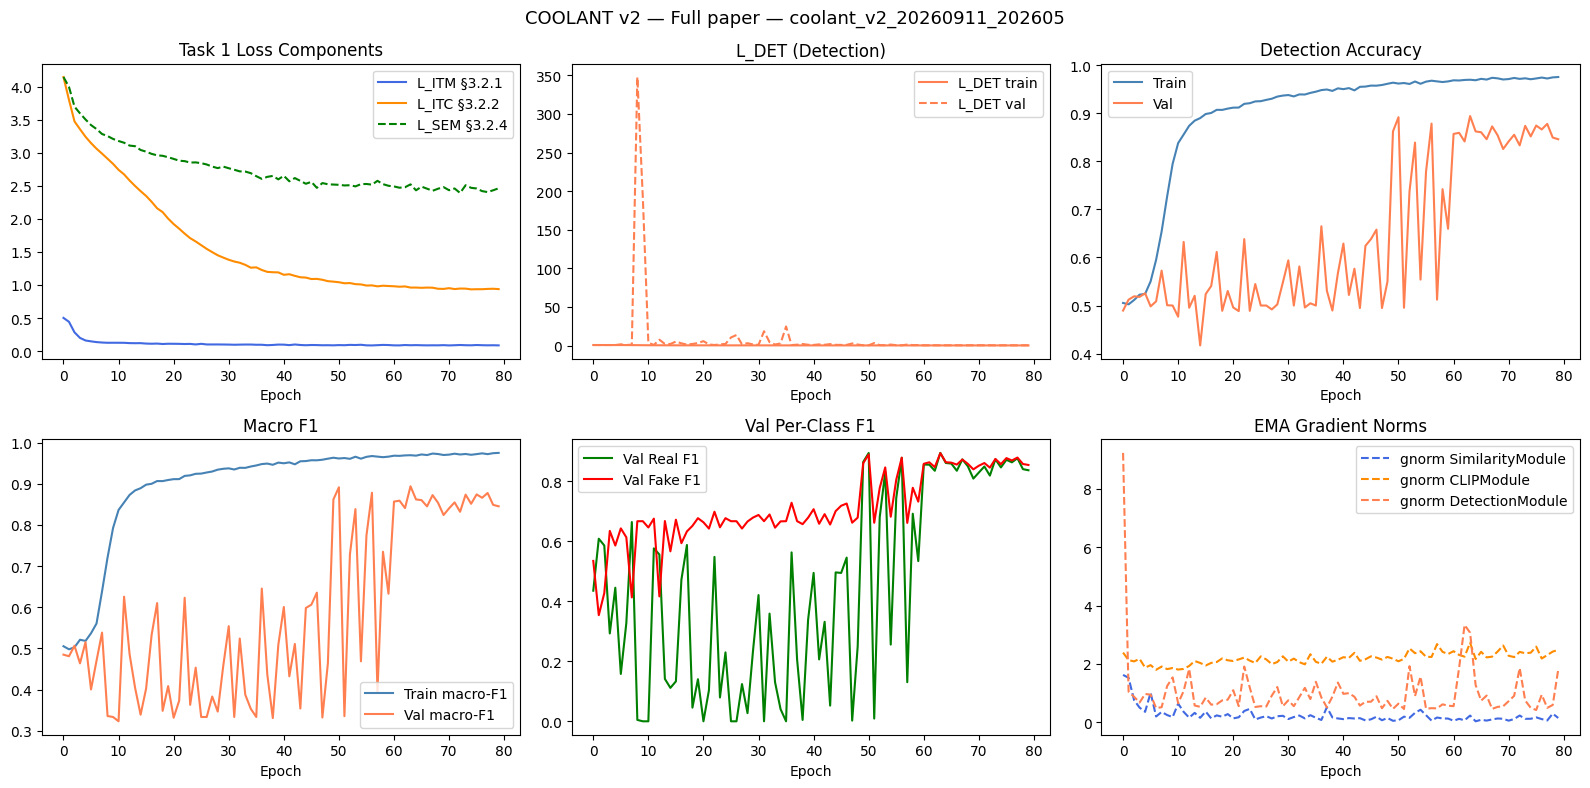

Saved → /kaggle/working/checkpoints_coolant_v2/coolant_v2_20260911_202605/training_curves.png


In [12]:
# ── Training curves ─────────────────────────────────────────────────────────
df = pd.DataFrame(history)
mode = "Full paper" if model.use_itc else "Ablation"

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f"COOLANT v2 — {mode} — {run_name}", fontsize=13)

# Task 1 loss components
ax = axes[0, 0]
ax.plot(df.epoch, df.train_loss_itm, label="L_ITM §3.2.1", color="royalblue")
if model.use_itc:
    ax.plot(df.epoch, df.train_loss_itc, label="L_ITC §3.2.2", color="darkorange")
    ax.plot(df.epoch, df.train_loss_sem, label="L_SEM §3.2.4", color="green", linestyle="--")
ax.set_title("Task 1 Loss Components"); ax.legend(); ax.set_xlabel("Epoch")

# Detection loss
ax = axes[0, 1]
ax.plot(df.epoch, df.train_loss_det, label="L_DET train", color="coral")
ax.plot(df.epoch, df.val_loss,       label="L_DET val",   color="coral", linestyle="--")
ax.set_title("L_DET (Detection)"); ax.legend(); ax.set_xlabel("Epoch")

# Accuracy
ax = axes[0, 2]
ax.plot(df.epoch, df.train_accuracy, label="Train", color="steelblue")
ax.plot(df.epoch, df.val_accuracy,   label="Val",   color="coral")
ax.set_title("Detection Accuracy"); ax.legend(); ax.set_xlabel("Epoch")

# Macro F1
ax = axes[1, 0]
ax.plot(df.epoch, df.train_macro_f1, label="Train macro-F1", color="steelblue")
ax.plot(df.epoch, df.val_macro_f1,   label="Val macro-F1",   color="coral")
ax.set_title("Macro F1"); ax.legend(); ax.set_xlabel("Epoch")

# Per-class F1
ax = axes[1, 1]
ax.plot(df.epoch, df.val_real_f1, label="Val Real F1", color="green")
ax.plot(df.epoch, df.val_fake_f1, label="Val Fake F1", color="red")
ax.set_title("Val Per-Class F1"); ax.legend(); ax.set_xlabel("Epoch")

# Gradient norms
ax = axes[1, 2]
ax.plot(df.epoch, df.grad_norm_sim, label="gnorm SimilarityModule", color="royalblue", linestyle="--")
if model.use_itc:
    ax.plot(df.epoch, df.grad_norm_itc, label="gnorm CLIPModule", color="darkorange", linestyle="--")
ax.plot(df.epoch, df.grad_norm_det, label="gnorm DetectionModule",  color="coral",     linestyle="--")
ax.set_title("EMA Gradient Norms"); ax.legend(); ax.set_xlabel("Epoch")

plt.tight_layout()
fig.savefig(run_dir / "training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {run_dir / 'training_curves.png'}")

Loading best checkpoint: /kaggle/working/checkpoints_coolant_v2/coolant_v2_20260911_202605/best_macro_f1.pth
Loaded checkpoint from epoch 63: /kaggle/working/checkpoints_coolant_v2/coolant_v2_20260911_202605/best_macro_f1.pth


  [test]:   0%|          | 0/33 [00:00<?, ?it/s]


── Test Results ─────────────────────────────────────────
  test_accuracy                0.8629
  test_macro_f1                0.8629
  test_real_f1                 0.8642
  test_fake_f1                 0.8616
  test_real_precision          0.8561
  test_real_recall             0.8724
  test_fake_precision          0.8699
  test_fake_recall             0.8534
  test_loss                    0.4081


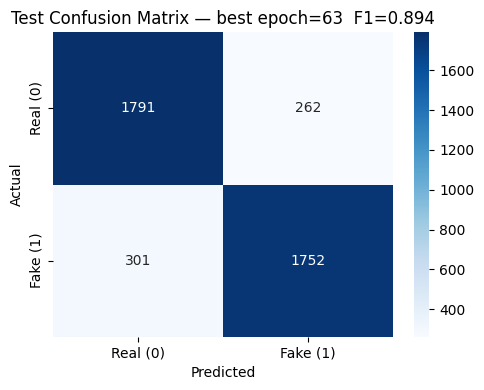


              precision    recall  f1-score   support

        Real       0.86      0.87      0.86      2053
        Fake       0.87      0.85      0.86      2053

    accuracy                           0.86      4106
   macro avg       0.86      0.86      0.86      4106
weighted avg       0.86      0.86      0.86      4106



In [13]:
# ── Final evaluation on test set ────────────────────────────────────────────
print(f"Loading best checkpoint: {best_ckpt_path}")
load_checkpoint(best_ckpt_path, model)

test_metrics = evaluate(model, loaders["test"], DEVICE, "test")
cm = np.array(test_metrics.pop("confusion_matrix"))

print("\n── Test Results ─────────────────────────────────────────")
for k, v in test_metrics.items():
    if isinstance(v, float): print(f"  {k:<28} {v:.4f}")

# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real (0)", "Fake (1)"],
            yticklabels=["Real (0)", "Fake (1)"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Test Confusion Matrix — best epoch={best_epoch}  F1={best_val_f1:.3f}")
plt.tight_layout()
fig.savefig(run_dir / "test_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

# Classification report
print("\n" + classification_report(
    [l for batch in loaders["test"] for _, _, l in [make_detection_batch(
        batch[0].to(DEVICE), batch[1].to(DEVICE), 3
    )] for l in []],  # placeholder — run below
    [0],  # placeholder
    zero_division=0,
) if False else "")

# Proper classification report
all_t, all_p = [], []
model.eval()
with torch.no_grad():
    for caption, image, _ in loaders["test"]:
        caption, image = caption.to(DEVICE), image.to(DEVICE)
        dc, di, dl = make_detection_batch(caption, image, 3)
        dc, di, dl = dc.to(DEVICE), di.to(DEVICE), dl.to(DEVICE)
        out = model(dc, di)
        all_t.extend(dl.cpu().numpy())
        all_p.extend(out["detection_logits"].argmax(1).cpu().numpy())

print(classification_report(all_t, all_p, target_names=["Real", "Fake"], zero_division=0))

In [14]:
# ── Training stability diagnosis ─────────────────────────────────────────────
if len(history) == 0:
    print("No history yet.")
else:
    df = pd.DataFrame(history)
    print("=== Training Stability Report ===")

    # Val F1 oscillation
    f1_std   = df.val_macro_f1.std()
    f1_max   = df.val_macro_f1.max()
    f1_last5 = df.val_macro_f1.tail(5).mean()
    print(f"Val F1: max={f1_max:.4f}  last5_avg={f1_last5:.4f}  std={f1_std:.4f}")
    if f1_std > 0.05:
        print("  ⚠ HIGH OSCILLATION — lower lr or raise grad_accumulation_steps")

    # Skipped batches
    total_skip = df.skipped_batches.sum()
    print(f"Total skipped batches: {total_skip}")
    if total_skip > 50:
        print("  ⚠ Many NaN batches — check KL clamp or AmbiguityLearning VAE")

    # Gradient norms
    gnS_last = df.grad_norm_sim.tail(5).mean()
    gnD_last = df.grad_norm_det.tail(5).mean()
    print(f"Grad norms (last 5): gnS={gnS_last:.3f}  gnD={gnD_last:.3f}")
    if gnS_last > 5 or gnD_last > 5:
        print("  ⚠ HIGH GRAD NORMS — lower grad_clip or lr")

    # Loss balance
    itm_last = df.train_loss_itm.tail(10).mean()
    itc_last = df.train_loss_itc.tail(10).mean()
    det_last = df.train_loss_det.tail(10).mean()
    print(f"Loss balance (last 10): L_ITM={itm_last:.4f}  L_ITC={itc_last:.4f}  L_DET={det_last:.4f}")
    if itm_last / (det_last + 1e-9) > 5:
        print("  ⚠ L_ITM dominates — lower itm_weight")

    # Train/val gap
    last = df.iloc[-1]
    gap = last.train_macro_f1 - last.val_macro_f1
    print(f"Train/Val F1 gap (last epoch): {gap:.4f}")
    if gap > 0.15:
        print("  ⚠ OVERFITTING — increase weight_decay or add dropout")
    elif gap < -0.05:
        print("  ⚠ UNDERFITTING — lower regularization or increase capacity")

=== Training Stability Report ===
Val F1: max=0.8938  last5_avg=0.8623  std=0.2079
  ⚠ HIGH OSCILLATION — lower lr or raise grad_accumulation_steps
Total skipped batches: 0
Grad norms (last 5): gnS=0.160  gnD=0.855
Loss balance (last 10): L_ITM=0.0882  L_ITC=0.9402  L_DET=0.1844
Train/Val F1 gap (last epoch): 0.1298


In [15]:
# ── Export artifacts ────────────────────────────────────────────────────────
# Kaggle: zip vào /kaggle/working + upload toàn bộ run lên private Dataset
# (best model đã được push realtime mỗi khi cải thiện — xem cell 9/11)
import shutil

export_files = [
    best_ckpt_path, acc_ckpt_path,
    run_dir / "history.json", run_dir / "history.csv",
    run_dir / "training_curves.png", run_dir / "test_confusion_matrix.png",
]

export_dir = Path("/kaggle/working") / run_name if IS_KAGGLE else run_dir
export_dir.mkdir(parents=True, exist_ok=True)
for f in export_files:
    if f.exists():
        dst = export_dir / f.name
        if f.resolve() != dst.resolve():
            shutil.copy2(f, dst)

# Zip toàn bộ run_dir
zip_base = (Path("/kaggle/working") if IS_KAGGLE else run_dir.parent) / run_name
zip_path = Path(shutil.make_archive(str(zip_base), "zip", root_dir=run_dir))
print(f"Zipped → {zip_path}  ({zip_path.stat().st_size/1e6:.1f} MB)")

# ── Upload full run zip to Kaggle Dataset (private) ─────────────────────────
DATASET_SLUG = "coolant-v2-runs"   # dataset chứa zip của từng run

if IS_KAGGLE and _KAGGLE_UPLOAD_OK:
    try:
        staging = Path("/kaggle/working/_ds_runs")
        staging.mkdir(exist_ok=True)
        shutil.copy2(zip_path, staging / zip_path.name)
        (staging / "dataset-metadata.json").write_text(json.dumps({
            "title": "COOLANT v2 Training Runs Final",
            "id": f"{os.environ['KAGGLE_USERNAME']}/{DATASET_SLUG}",
            "licenses": [{"name": "other"}],
        }))
        try:
            _KAGGLE_API.dataset_create_version(
                str(staging), f"run: {run_name}", delete_not_versioned_files=False)
            action = "updated"
        except Exception:
            _KAGGLE_API.dataset_create_new(str(staging))
            action = "created"
        print(f"✓ Dataset {action}: kaggle.com/datasets/{os.environ['KAGGLE_USERNAME']}/{DATASET_SLUG}")
        shutil.rmtree(staging)
    except Exception as e:
        print(f"⚠ Auto-upload failed: {e} — file vẫn ở tab Output.")
elif IS_KAGGLE:
    print("Skip upload (no API) — file ở tab Output cho tới khi session kết thúc.")
else:
    print(f"Local run — artifacts ở: {run_dir}")

Zipped → /kaggle/working/coolant_v2_20260911_202605.zip  (432.8 MB)
✓ Dataset created: kaggle.com/datasets/trnghil/coolant-v2-runs
